Design Parameter Distributions


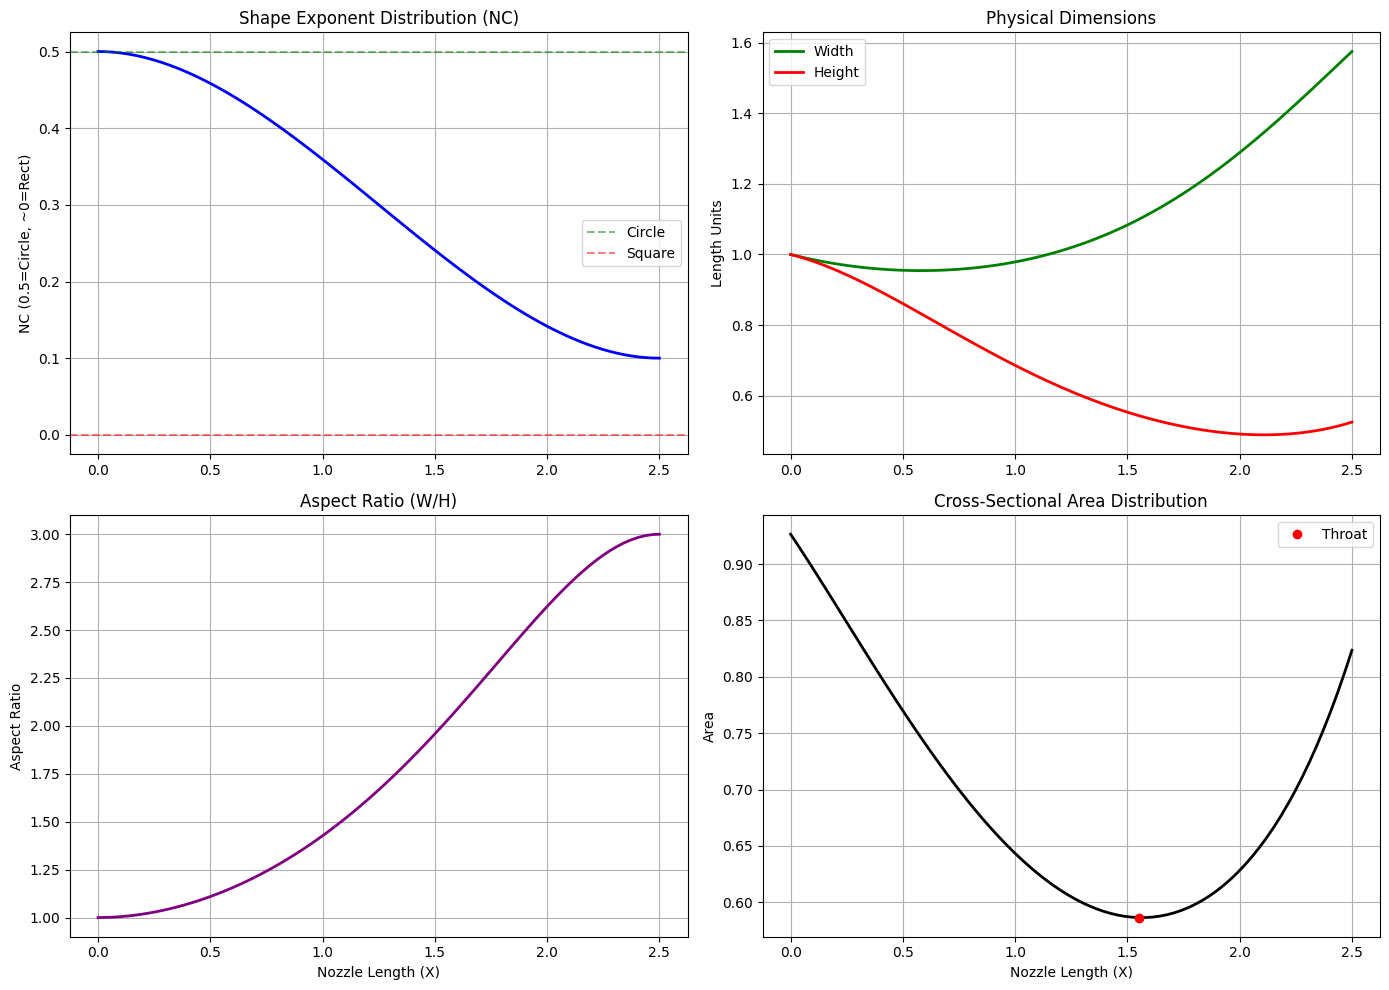

Plotting 3D Geometry


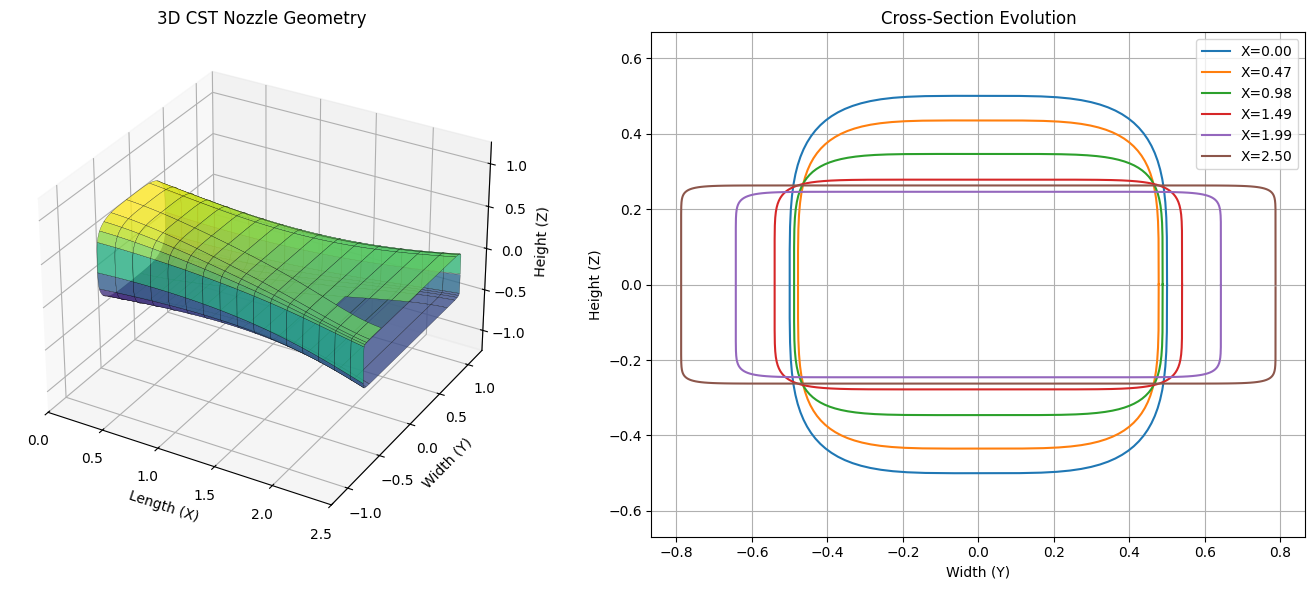

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import csv

class CSTNozzleDesigner:

    def __init__(self, length=1.0, n_longitudinal=500, n_cross=750):
        self.L = length
        self.n_psi = n_longitudinal
        self.n_eta = n_cross

        # PSI: Longitudinal Station (0.0 to 1.0)
        self.psi = np.linspace(0, 1, self.n_psi)

        self.nc_dist = None
        self.width_dist = None
        self.height_dist = None
        self.area_dist = None

    def _bernstein_poly(self, n, i, val):
        import scipy.special
        binom = scipy.special.comb(n, i)
        return binom * (val**i) * ((1 - val)**(n - i))

    def _cst_class_function(self, val, N1, N2):
        val = np.clip(val, 0.0, 1.0)
        return (val**N1) * ((1 - val)**N2)

    def _cst_shape_function(self, val, weights):
        n = len(weights) - 1
        S = np.zeros_like(val)
        for i in range(n + 1):
            S += weights[i] * self._bernstein_poly(n, i, val)
        return S

    def _get_super_ellipse_profile_continuous(self, width, height, N_exp):

        t = np.linspace(0, 2 * np.pi, self.n_eta)

        p = N_exp
        if p < 1e-4: p = 1e-4

        y_vals = (width / 2.0) * np.sign(np.cos(t)) * (np.abs(np.cos(t)))**p
        z_vals = (height / 2.0) * np.sign(np.sin(t)) * (np.abs(np.sin(t)))**p

        return y_vals, z_vals

    def _calculate_cross_section_area(self, width, height, N_exp):

        y, z = self._get_super_ellipse_profile_continuous(width, height, N_exp)
        return 0.5 * np.abs(np.dot(y, np.roll(z, 1)) - np.dot(z, np.roll(y, 1)))

    def generate_geometry(self, inlet_params, outlet_params, area_weights):

        C_long = self._cst_class_function(self.psi, 0.0, 0.0)
        S_long = self._cst_shape_function(self.psi, area_weights)

        S_long = S_long / S_long[0]
        envelope_scale = C_long * S_long

        smooth_t = 3 * self.psi**2 - 2 * self.psi**3

        nc_in = inlet_params['shape_exp']
        nc_out = outlet_params['shape_exp']
        self.nc_dist = nc_in + (nc_out - nc_in) * smooth_t

        w_in = inlet_params['diameter']
        h_in = inlet_params['diameter']
        w_out = outlet_params['width']
        h_out = outlet_params['height']

        ref_w_dist = w_in + (w_out - w_in) * smooth_t
        ref_h_dist = h_in + (h_out - h_in) * smooth_t

        self.width_dist = ref_w_dist * envelope_scale
        self.height_dist = ref_h_dist * envelope_scale

        self.area_dist = np.zeros_like(self.psi)

        X_3d = np.zeros((self.n_psi, self.n_eta))
        Y_3d = np.zeros((self.n_psi, self.n_eta))
        Z_3d = np.zeros((self.n_psi, self.n_eta))

        for i, p in enumerate(self.psi):
            x_loc = p * self.L

            y_sect, z_sect = self._get_super_ellipse_profile_continuous(
                self.width_dist[i], self.height_dist[i], self.nc_dist[i]
            )

            X_3d[i, :] = x_loc
            Y_3d[i, :] = y_sect
            Z_3d[i, :] = z_sect

            self.area_dist[i] = self._calculate_cross_section_area(
                self.width_dist[i], self.height_dist[i], self.nc_dist[i]
            )

        self.X, self.Y, self.Z = X_3d, Y_3d, Z_3d
        return X_3d, Y_3d, Z_3d

    def plot_geometry(self):
        fig = plt.figure(figsize=(14, 6))

        ax1 = fig.add_subplot(1, 2, 1, projection='3d')
        surf = ax1.plot_surface(self.X, self.Y, self.Z, cmap='viridis',
                               alpha=0.8, edgecolor='k', linewidth=0.2, rstride=5, cstride=5)
        ax1.set_xlabel('Length (X)')
        ax1.set_ylabel('Width (Y)')
        ax1.set_zlabel('Height (Z)')
        ax1.set_title('3D CST Nozzle Geometry')

        max_range = np.array([self.X.max()-self.X.min(),
                              self.Y.max()-self.Y.min(),
                              self.Z.max()-self.Z.min()]).max() / 2.0
        mid_x = (self.X.max()+self.X.min()) * 0.5
        mid_y = (self.Y.max()+self.Y.min()) * 0.5
        mid_z = (self.Z.max()+self.Z.min()) * 0.5
        ax1.set_xlim(mid_x - max_range, mid_x + max_range)
        ax1.set_ylim(mid_y - max_range, mid_y + max_range)
        ax1.set_zlim(mid_z - max_range, mid_z + max_range)

        # Plot 2: Cross-Sections
        ax2 = fig.add_subplot(1, 2, 2)
        stations = np.linspace(0, self.n_psi-1, 6).astype(int)

        for idx in stations:
            x_val = self.X[idx, 0]
            ax2.plot(self.Y[idx, :], self.Z[idx, :], label=f'X={x_val:.2f}')

        ax2.set_xlabel('Width (Y)')
        ax2.set_ylabel('Height (Z)')
        ax2.set_title('Cross-Section Evolution')
        ax2.grid(True)
        ax2.legend()
        ax2.axis('equal')

        plt.tight_layout()
        plt.show()

    def plot_design_curves(self):

        if self.nc_dist is None:
            print("Error: Generate geometry first!")
            return

        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        x_vals = self.psi * self.L

        # Plot 1: Shape Exponent (NC)
        axs[0, 0].plot(x_vals, self.nc_dist, 'b-', lw=2)
        axs[0, 0].set_title('Shape Exponent Distribution (NC)')
        axs[0, 0].set_ylabel('NC (0.5=Circle, ~0=Rect)')
        axs[0, 0].grid(True)
        axs[0, 0].axhline(0.5, color='green', linestyle='--', alpha=0.5, label='Circle')
        axs[0, 0].axhline(0.0, color='red', linestyle='--', alpha=0.5, label='Square')
        axs[0, 0].legend()

        # Plot 2: Width and Height
        axs[0, 1].plot(x_vals, self.width_dist, 'g-', lw=2, label='Width')
        axs[0, 1].plot(x_vals, self.height_dist, 'r-', lw=2, label='Height')
        axs[0, 1].set_title('Physical Dimensions')
        axs[0, 1].set_ylabel('Length Units')
        axs[0, 1].grid(True)
        axs[0, 1].legend()

        # Plot 3: Aspect Ratio (W/H)
        aspect_ratio = self.width_dist / self.height_dist
        axs[1, 0].plot(x_vals, aspect_ratio, 'purple', lw=2)
        axs[1, 0].set_title('Aspect Ratio (W/H)')
        axs[1, 0].set_xlabel('Nozzle Length (X)')
        axs[1, 0].set_ylabel('Aspect Ratio')
        axs[1, 0].grid(True)

        # Plot 4: Cross-Sectional Area
        axs[1, 1].plot(x_vals, self.area_dist, 'k-', lw=2)
        axs[1, 1].set_title('Cross-Sectional Area Distribution')
        axs[1, 1].set_xlabel('Nozzle Length (X)')
        axs[1, 1].set_ylabel('Area')
        axs[1, 1].grid(True)

        # Highlight Throat (Minimum Area)
        min_area_idx = np.argmin(self.area_dist)
        axs[1, 1].plot(x_vals[min_area_idx], self.area_dist[min_area_idx], 'ro', label='Throat')
        axs[1, 1].legend()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":

    nozzle = CSTNozzleDesigner(length=2.5, n_longitudinal=80, n_cross=100)

    # Inlet: Circular (NC=0.5)
    inlet_cfg = {'diameter': 1.0, 'shape_exp': 0.5}

    # Outlet: Rectangular (NC=0.05 for sharp corners)
    outlet_cfg = {'width': 1.5, 'height': 0.5, 'shape_exp': 0.1}


    area_weights = [1.0, 0.9, 0.7, 0.8, 1.05]

    # 3. Generate Geometry
    nozzle.generate_geometry(inlet_cfg, outlet_cfg, area_weights)

    # 4. Plot Design Curves (NC, W/H, Area)
    print("Design Parameter Distributions")
    nozzle.plot_design_curves()

    # 5. Plot 3D Geometry
    print("Plotting 3D Geometry")
    nozzle.plot_geometry()

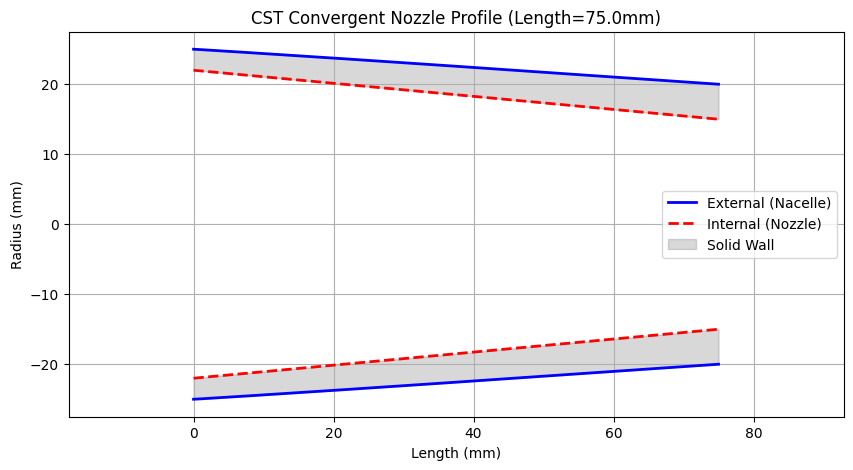

Geometry successfully saved to cst_convergent_nozzle.stl


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

class CSTGeometryGenerator:
    """
    Generates geometry using the Class Function / Shape Function (CST) method
    as defined by Brenda M. Kulfan (2008).
    """
    def __init__(self, length_mm):
        self.length = length_mm

    def bernstein_poly(self, x, r, n):
        """
        Calculates the Bernstein polynomial term B_{r,n}(x).
        Equation (9) from the paper.
        """
        binom_coeff = math.factorial(n) / (math.factorial(r) * math.factorial(n - r))
        return binom_coeff * (x**r) * ((1 - x)**(n - r))

    def calculate_cst_radius(self, psi, n1, n2, coeffs, r_inlet, r_exit):
        """
        Calculates the radius at normalized location psi (0 to 1).

        Args:
            psi: Normalized x-coordinate (0.0 to 1.0)
            n1, n2: Class function exponents (0.5, 1.0 is standard airfoil-like)
            coeffs: List of Bernstein coefficients (Weights for shape function)
            r_inlet: Radius at x=0
            r_exit: Radius at x=L

        Returns:
            Radius value.
        """
        # 1. Class Function C(psi) (Eq. 6)
        # N1=0.5, N2=1.0 gives round nose, sharp aft characteristics
        C = (psi**n1) * ((1 - psi)**n2)

        # 2. Shape Function S(psi) (Eq. 3 & 8)
        # Summation of Bernstein polynomials scaled by coefficients
        n_order = len(coeffs) - 1
        S = sum(coeffs[i] * self.bernstein_poly(psi, i, n_order) for i in range(len(coeffs)))

        # 3. Structural/Thickness Offsets (Handling Open Ends)
        # The paper describes "Airfoil Decomposition" (Fig 5).
        # We model the duct as a base linear tube + CST shape bump.
        # Base Shape: Linear transition from Inlet Radius to Exit Radius
        base_radius = r_inlet * (1 - psi) + r_exit * psi

        # Combine: R = Base + C * S
        radius = base_radius + C * S
        return radius

    def generate_profile(self, num_points=200, **params):
        """
        Generates the X, Z coordinates for a profile.
        """
        psi_vals = np.linspace(0, 1, num_points)
        x_vals = psi_vals * self.length
        z_vals = []

        for psi in psi_vals:
            r = self.calculate_cst_radius(
                psi,
                params['n1'],
                params['n2'],
                params['coeffs'],
                params['r_inlet'],
                params['r_exit']
            )
            z_vals.append(r)

        return x_vals, np.array(z_vals)

def write_stl(filename, x_outer, r_outer, x_inner, r_inner, angular_res=72):
    """
    Writes a binary or ASCII STL file of the revolved 3D geometry.
    This creates a solid watertight volume with thickness.
    """

    # Combine profiles into a continuous loop for the cross-section
    # 1. Outer profile (0 to L)
    # 2. Back face (Outer exit to Inner exit)
    # 3. Inner profile (L to 0) - Reversed
    # 4. Front face (Inner inlet to Outer inlet)

    # Vertices generation
    thetas = np.linspace(0, 2*np.pi, angular_res, endpoint=False)
    # Close the loop
    thetas = np.append(thetas, 0)

    # Open file
    with open(filename, 'w') as f:
        f.write("solid cst_nozzle\n")

        def write_facet(v1, v2, v3):
            # Calculate normal
            u = v2 - v1
            v = v3 - v1
            n = np.cross(u, v)
            norm = np.linalg.norm(n)
            if norm > 0: n /= norm

            f.write(f"facet normal {n[0]:.4f} {n[1]:.4f} {n[2]:.4f}\n")
            f.write("outer loop\n")
            f.write(f"vertex {v1[0]:.4f} {v1[1]:.4f} {v1[2]:.4f}\n")
            f.write(f"vertex {v2[0]:.4f} {v2[1]:.4f} {v2[2]:.4f}\n")
            f.write(f"vertex {v3[0]:.4f} {v3[1]:.4f} {v3[2]:.4f}\n")
            f.write("endloop\nendfacet\n")

        # Function to rotate a 2D point (x, r) to 3D (x, y, z)
        def to_3d(x, r, theta):
            return np.array([x, r * np.cos(theta), r * np.sin(theta)])

        # -- Generate Mesh --
        # We mesh strips between angular steps

        # 1. Outer Surface
        for i in range(len(x_outer) - 1):
            for j in range(len(thetas) - 1):
                t1, t2 = thetas[j], thetas[j+1]

                # Points for current segment
                p1 = to_3d(x_outer[i], r_outer[i], t1)
                p2 = to_3d(x_outer[i], r_outer[i], t2)
                p3 = to_3d(x_outer[i+1], r_outer[i+1], t2)
                p4 = to_3d(x_outer[i+1], r_outer[i+1], t1)

                # Two triangles per quad
                write_facet(p1, p2, p3)
                write_facet(p1, p3, p4)

        # 2. Inner Surface (Note: Normal direction inverted for inner surface)
        for i in range(len(x_inner) - 1):
            for j in range(len(thetas) - 1):
                t1, t2 = thetas[j], thetas[j+1]

                p1 = to_3d(x_inner[i], r_inner[i], t1)
                p2 = to_3d(x_inner[i], r_inner[i], t2)
                p3 = to_3d(x_inner[i+1], r_inner[i+1], t2)
                p4 = to_3d(x_inner[i+1], r_inner[i+1], t1)

                # Invert order for inner surface to point normals inward relative to axis
                # (which is outward relative to solid wall)
                write_facet(p4, p3, p2)
                write_facet(p4, p2, p1)

        # 3. Front Lip (Connecting Outer[0] to Inner[0])
        # A simple flat ring, or could be rounded. Here we verify x is same.
        for j in range(len(thetas) - 1):
            t1, t2 = thetas[j], thetas[j+1]

            p1_out = to_3d(x_outer[0], r_outer[0], t1)
            p2_out = to_3d(x_outer[0], r_outer[0], t2)
            p1_in  = to_3d(x_inner[0], r_inner[0], t1)
            p2_in  = to_3d(x_inner[0], r_inner[0], t2)

            # Normals pointing -x
            write_facet(p1_out, p2_in, p1_in)
            write_facet(p1_out, p2_out, p2_in)

        # 4. Back Face (Connecting Outer[-1] to Inner[-1])
        for j in range(len(thetas) - 1):
            t1, t2 = thetas[j], thetas[j+1]

            p1_out = to_3d(x_outer[-1], r_outer[-1], t1)
            p2_out = to_3d(x_outer[-1], r_outer[-1], t2)
            p1_in  = to_3d(x_inner[-1], r_inner[-1], t1)
            p2_in  = to_3d(x_inner[-1], r_inner[-1], t2)

            # Normals pointing +x
            write_facet(p1_out, p1_in, p2_in)
            write_facet(p1_out, p2_in, p2_out)

        f.write("endsolid cst_nozzle\n")
    print(f"Geometry successfully saved to {filename}")

# ==========================================
# Main Execution
# ==========================================

# 1. Setup Parameters
L = 75.0  # Length mm (Specified in Prompt)

# Define CST Coefficients (The "Finetuning")
# These A_i coefficients control the Bernstein polynomials.
# Values chosen to create a realistic aerodynamic Nacelle shape.

# External Profile (Nacelle)
# Round nose, thickest at ~35% chord, boattail taper at end.
# N1=0.5 (Round Nose), N2=1.0 (Sharp Aft decay)
ext_params = {
    'n1': 0.5,
    'n2': 1.0,
    # Coefficients [A0, A1, A2, A3, A4, A5]
    # A0 controls LE radius, higher A_mid gives thickness, Lower A_end gives taper
    'coeffs': [0.12, 0.18, 0.22, 0.20, 0.14, 0.08],
    'r_inlet': 25.0,  # Inlet Radius (Lip)
    'r_exit': 20.0    # Outer Exit Radius
}

# Internal Profile (Convergent Nozzle)
# Smooth convergence from inlet to exit.
# N1=0.5, N2=1.0 ensures smooth flow path
int_params = {
    'n1': 0.5,
    'n2': 1.0,
    # Coefficients chosen to maintain a smooth convergent duct
    # Small negative coeffs or small positive helps shape the pressure gradient
    'coeffs': [0.0, 0.02, 0.03, 0.02, 0.01, 0.0],
    'r_inlet': 22.0,  # Inner Inlet Radius (Wall thickness = 3mm)
    'r_exit': 15.0    # Inner Exit Radius (Throat/Exit) -> Convergent
}

# 2. Generate 2D Profiles
generator = CSTGeometryGenerator(L)
x_out, r_out = generator.generate_profile(**ext_params)
x_in, r_in = generator.generate_profile(**int_params)

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(x_out, r_out, 'b-', label='External (Nacelle)', linewidth=2)
plt.plot(x_in, r_in, 'r--', label='Internal (Nozzle)', linewidth=2)
plt.plot(x_out, -r_out, 'b-', linewidth=2) # Mirror for visualization
plt.plot(x_in, -r_in, 'r--', linewidth=2)
plt.fill_between(x_out, r_in, r_out, color='gray', alpha=0.3, label='Solid Wall')
plt.fill_between(x_out, -r_out, -r_in, color='gray', alpha=0.3)
plt.axis('equal')
plt.title(f'CST Convergent Nozzle Profile (Length={L}mm)')
plt.xlabel('Length (mm)')
plt.ylabel('Radius (mm)')
plt.grid(True)
plt.legend()
plt.show()

# 4. Generate 3D STL
write_stl('cst_convergent_nozzle.stl', x_out, r_out, x_in, r_in, angular_res=100)

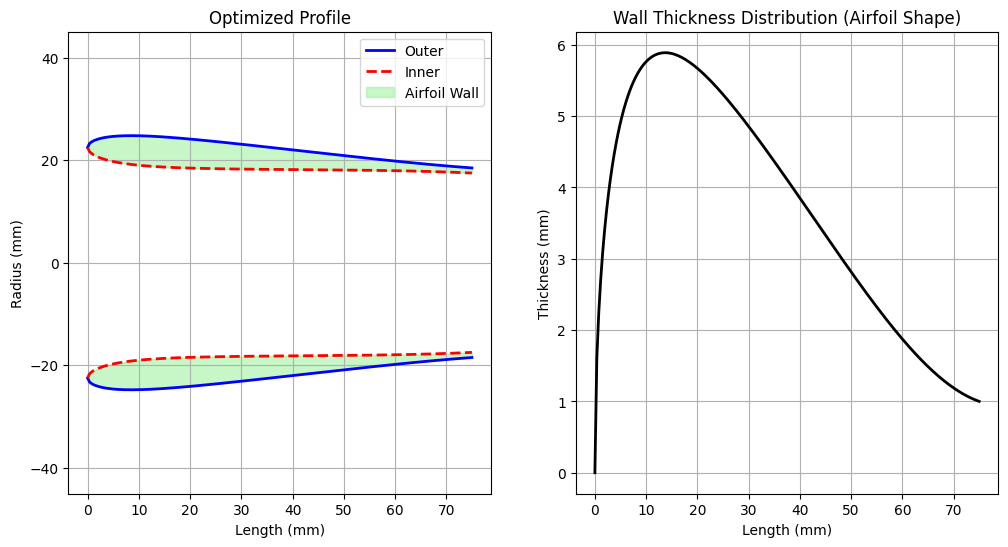

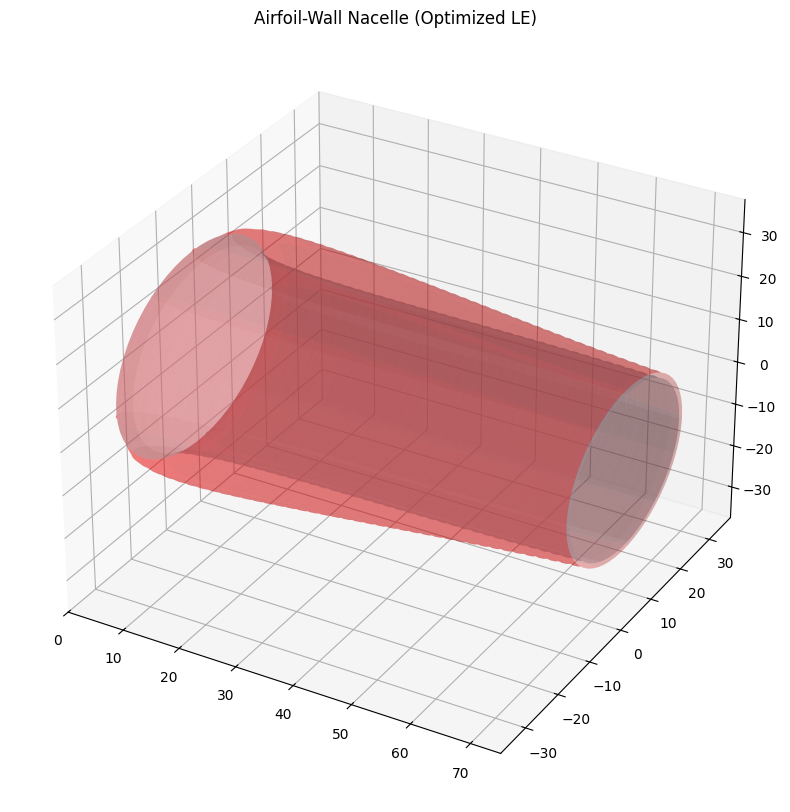

STL saved to airfoil_wall_nozzle.stl


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import comb
from scipy.optimize import minimize

class CSTAirfoilNacelle:

    def __init__(self, length_mm):
        self.L = length_mm

    def bernstein(self, r, n, psi):
        return comb(n, r) * (psi**r) * ((1 - psi)**(n - r))

    def cst_curve(self, psi, coeffs):

        C = (psi**0.5) * ((1 - psi)**1.0) # Class function (Round Nose / Sharp Aft)
        n = len(coeffs) - 1
        S = np.zeros_like(psi)
        for i in range(n + 1):
            S += coeffs[i] * self.bernstein(i, n, psi)
        return C * S

    def get_geometry(self, n_points=200,

                     t_max=6.0,       # Max wall thickness (mm)
                     t_x_max=0.35,    # Location of max thickness (35% chord)
                     r_le_wall=3.0,   # Leading Edge Radius of the WALL (Roundness)
                     t_te=2,        # Trailing Edge thickness (Sharpness at exit)

                     r_mean_inlet=23.5, # Center of the lip at inlet
                     r_mean_exit=19.5   # Center of the wall at exit
                     ):

        psi = np.linspace(0, 1, n_points)
        x = psi * self.L

        # A0_thickness = sqrt(2 * R_LE / L)
        # Note: This R_LE is for the wall cross-section, not the duct.
        a0_thick = np.sqrt(2 * (r_le_wall / self.L))

        def thick_obj(vars):
            coeffs = [a0_thick] + list(vars)

            t_calc = self.cst_curve(np.array([t_x_max]), coeffs)[0] * self.L
            # We add linear tail thickness: T_total = CST + x * t_te
            t_total = t_calc + t_x_max * t_te
            return (t_total - t_max)**2

        # Solve for thickness shape
        res_t = minimize(thick_obj, [0.1, 0.1, 0.1, 0.1], method='Nelder-Mead')
        thick_coeffs = [a0_thick] + list(res_t.x)

        # Calculate Thickness Curve
        bump = self.cst_curve(psi, thick_coeffs) * self.L
        # Add linear taper to finite trailing edge
        thickness = bump + psi * t_te

        def camber_obj(vars):
            coeffs = [0.0] + list(vars) + [0.0]

            y = self.cst_curve(np.linspace(0, 0.2, 20), coeffs)
            curvature = np.sum(np.diff(np.diff(y))**2)
            return curvature

        r_linear = r_mean_inlet * (1 - psi) + r_mean_exit * psi

        res_c = minimize(camber_obj, [0.05, 0.05], method='Nelder-Mead')
        camber_coeffs = [0.0] + list(res_c.x) + [0.0]

        r_camber_bump = self.cst_curve(psi, camber_coeffs) * self.L
        r_mean = r_linear + r_camber_bump

        r_outer = r_mean + thickness / 2.0
        r_inner = r_mean - thickness / 2.0

        return x, r_outer, r_inner, thickness

def plot_3d_nozzle(x, r_out, r_in):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    theta = np.linspace(0, 2*np.pi, 60)
    grid_theta, grid_x = np.meshgrid(theta, x)

    Y_out = r_out[:, None] * np.cos(grid_theta)
    Z_out = r_out[:, None] * np.sin(grid_theta)
    Y_in  = r_in[:, None]  * np.cos(grid_theta)
    Z_in  = r_in[:, None]  * np.sin(grid_theta)

    ax.plot_surface(grid_x, Y_out, Z_out, color='lightblue', alpha=0.4, rstride=5, cstride=5)
    ax.plot_surface(grid_x, Y_in, Z_in, color='red', alpha=0.3, rstride=5, cstride=5)

    # Scale fix
    max_range = np.array([x.max()-x.min(), Y_out.max()-Y_out.min(), Z_out.max()-Z_out.min()]).max() / 2.0
    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (Y_out.max()+Y_out.min()) * 0.5
    mid_z = (Z_out.max()+Z_out.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_title("Airfoil-Wall Nacelle (Optimized LE)")
    plt.show()

def write_stl(filename, x, r_out, r_in, angular_res=72):
    theta = np.linspace(0, 2*np.pi, angular_res, endpoint=False)
    theta = np.append(theta, 0)

    with open(filename, 'w') as f:
        f.write(f"solid cst_nozzle\n")
        def write_facet(v1, v2, v3):
            u, v = v2-v1, v3-v1
            n = np.cross(u, v)
            norm = np.linalg.norm(n)
            n = n/norm if norm > 0 else n
            f.write(f"facet normal {n[0]:.4f} {n[1]:.4f} {n[2]:.4f}\nouter loop\n")
            for p in [v1, v2, v3]: f.write(f"vertex {p[0]:.4f} {p[1]:.4f} {p[2]:.4f}\n")
            f.write("endloop\nendfacet\n")

        for i in range(len(x)-1):
            for j in range(len(theta)-1):
                t1, t2 = theta[j], theta[j+1]
                c1, s1, c2, s2 = np.cos(t1), np.sin(t1), np.cos(t2), np.sin(t2)
                # Outer
                p1o = np.array([x[i], r_out[i]*c1, r_out[i]*s1])
                p2o = np.array([x[i], r_out[i]*c2, r_out[i]*s2])
                p3o = np.array([x[i+1], r_out[i+1]*c2, r_out[i+1]*s2])
                p4o = np.array([x[i+1], r_out[i+1]*c1, r_out[i+1]*s1])
                write_facet(p1o, p2o, p3o)
                write_facet(p1o, p3o, p4o)
                # Inner
                p1i = np.array([x[i], r_in[i]*c1, r_in[i]*s1])
                p2i = np.array([x[i], r_in[i]*c2, r_in[i]*s2])
                p3i = np.array([x[i+1], r_in[i+1]*c2, r_in[i+1]*s2])
                p4i = np.array([x[i+1], r_in[i+1]*c1, r_in[i+1]*s1])
                write_facet(p4i, p3i, p2i)
                write_facet(p4i, p2i, p1i)

        # Caps
        for j in range(len(theta)-1):
            t1, t2 = theta[j], theta[j+1]
            c1, s1, c2, s2 = np.cos(t1), np.sin(t1), np.cos(t2), np.sin(t2)
            # Lip
            p1o, p2o = [x[0], r_out[0]*c1, r_out[0]*s1], [x[0], r_out[0]*c2, r_out[0]*s2]
            p1i, p2i = [x[0], r_in[0]*c1, r_in[0]*s1], [x[0], r_in[0]*c2, r_in[0]*s2]
            write_facet(np.array(p1o), np.array(p2i), np.array(p1i))
            write_facet(np.array(p1o), np.array(p2o), np.array(p2i))
            # Exit
            p1o, p2o = [x[-1], r_out[-1]*c1, r_out[-1]*s1], [x[-1], r_out[-1]*c2, r_out[-1]*s2]
            p1i, p2i = [x[-1], r_in[-1]*c1, r_in[-1]*s1], [x[-1], r_in[-1]*c2, r_in[-1]*s2]
            write_facet(np.array(p1o), np.array(p1i), np.array(p2i))
            write_facet(np.array(p1o), np.array(p2i), np.array(p2o))

        f.write("endsolid cst_nozzle\n")
    print(f"STL saved to {filename}")

# --- Execution ---
L = 75.0
optimizer = CSTAirfoilNacelle(L)

x, r_out, r_in, thickness = optimizer.get_geometry(
    # Airfoil Wall Properties
    t_max=5.5,          # Max thickness 5.5mm (Thin but sturdy)
    t_x_max=0.30,       # Max thickness forward (30%) for better inlet performance
    r_le_wall=3.5,      # 3.5mm Nose Radius (Explicitly Rounded)
    t_te=1.0,           # Tapers to 1mm at exit

    # Duct Shape Properties
    r_mean_inlet=22.5,  # Lip centerline radius (Resulting Outer ~25, Inner ~20)
    r_mean_exit=18.0    # Exit centerline radius (Resulting Outer ~18.5, Inner ~17.5)
)

# 2D Validation
plt.figure(figsize=(12, 6))

# Profile
plt.subplot(1, 2, 1)
plt.plot(x, r_out, 'b-', linewidth=2, label='Outer')
plt.plot(x, r_in, 'r--', linewidth=2, label='Inner')
plt.plot(x, -r_out, 'b-', linewidth=2)
plt.plot(x, -r_in, 'r--', linewidth=2)
plt.fill_between(x, r_in, r_out, color='lightgreen', alpha=0.5, label='Airfoil Wall')
plt.fill_between(x, -r_in, -r_out, color='lightgreen', alpha=0.5)
plt.title(f"Optimized Profile")
plt.xlabel("Length (mm)")
plt.ylabel("Radius (mm)")
plt.axis('equal')
plt.grid(True)
plt.legend()

# Thickness Check
plt.subplot(1, 2, 2)
plt.plot(x, thickness, 'k-', linewidth=2)
plt.title("Wall Thickness Distribution (Airfoil Shape)")
plt.xlabel("Length (mm)")
plt.ylabel("Thickness (mm)")
plt.grid(True)
plt.show()

# 3D & STL
plot_3d_nozzle( x, r_in, r_out)
write_stl('airfoil_wall_nozzle.stl', x, r_in, r_out)

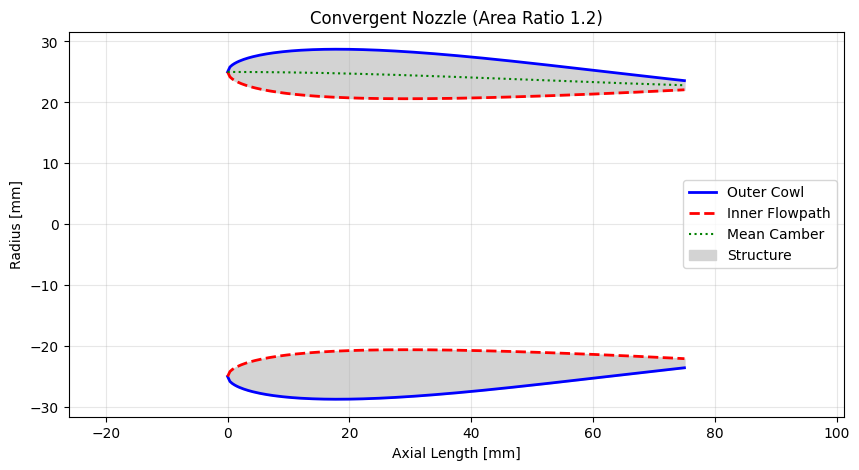

STL saved to convergent_nozzle.stl


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import comb

class CSTNozzleRobust:
    """
    Generates a Convergent Nozzle using the Mean Camber + Thickness approach.
    Guarantees horizontal inlet flow and perfectly rounded leading edge.
    """
    def __init__(self, length_mm):
        self.L = length_mm

    def bernstein(self, r, n, psi):
        """Bernstein Basis Polynomial"""
        return comb(n, r) * (psi**r) * ((1 - psi)**(n - r))

    def cst_shape_function(self, psi, coeffs):
        """Standard CST Shape Function S(psi)"""
        n = len(coeffs) - 1
        S = np.zeros_like(psi)
        for i in range(n + 1):
            S += coeffs[i] * self.bernstein(i, n, psi)
        return S

    def generate_geometry(self, n_points=200,
                          # 1. Geometry Targets
                          r_inlet_mean=25.0,  # Mean radius at inlet (x=0)
                          area_ratio=1.2,     # Inlet Area / Outlet Area

                          # 2. Wall Thickness (The Airfoil)
                          r_le_wall=3.5,      # Nose Radius (Matches Fig 31)
                          t_max=6.0,          # Max thickness of the cowl bulge
                          t_te=1.5            # Trailing edge thickness
                          ):

        # Calculate Outlet Target Radius based on Area Ratio
        # A_in = pi * r^2.  A_out = A_in / 1.2
        # r_out = r_in / sqrt(1.2)
        r_outlet_mean = r_inlet_mean / np.sqrt(area_ratio)

        # Normalized Domain
        psi = np.linspace(0, 1, n_points)
        x_mm = psi * self.L

        # --- A. Mean Camber Line (Horizontal Start) ---
        # Class Function N1=1.0, N2=1.0 (Simple curve)
        C_camber = (psi**1.0) * ((1 - psi)**1.0)

        # Linear Backbone: Connects Start to End
        r_linear = r_inlet_mean * (1 - psi) + r_outlet_mean * psi

        # CST Bump for Curvature
        # A0=0.0 guarantees the slope at x=0 matches the backbone.
        # But the backbone has a slope (r_out - r_in)/L.
        # To make the TOTAL slope 0 at x=0, the CST term must cancel the backbone slope.
        # Slope of Linear part = (r_outlet - r_inlet) / 1.0 (normalized) = delta_r
        # Slope of CST term C*S at psi=0 is A0.
        # NO, Derivative of C(psi) at 0 is finite.
        # Actually, simpler approach: Use a CST curve that *is* the deviation from horizontal.
        # R_mean = R_inlet + C_camber * S_camber + x * 0 (No linear vertical shift)
        # But we need to hit r_outlet.
        # Let's use the explicit constraint method.

        # We need R'(0) = 0.
        # Curve: R(psi) = R_linear(psi) + Bump(psi)
        # R'(psi) = (r_out - r_in) + Bump'(psi)
        # Bump'(0) must equal -(r_out - r_in) to cancel the slope.
        # For N1=1, N2=1, Bump'(0) = A0.
        # Therefore: A0 = r_inlet - r_outlet.

        A0_camber = r_inlet_mean - r_outlet_mean

        # Remaining coeffs define the "path" shape.
        # Negative coeffs will curve it smoothly.
        camber_coeffs = [A0_camber, A0_camber * 0.5, 0.0]

        S_camber = self.cst_shape_function(psi, camber_coeffs)

        # Apply scaling to S_camber if needed, but A0 calculation assumes unit scaling
        # R_mean = R_linear + (C * S)
        # Wait, if S(0)=A0, then C(0)*S(0) = 0*A0 = 0. Radius is correct.
        # Derivative: R' = Linear_Slope + C'*S + C*S'.
        # At 0: R' = Linear_Slope + 1*S(0) + 0 = Linear_Slope + A0.
        # So A0 = -Linear_Slope = -(r_out - r_in) = r_in - r_out.

        r_mean_bump = C_camber * S_camber
        r_mean = r_linear + r_mean_bump

        # --- B. Thickness Distribution (Airfoil) ---
        # Class N1=0.5, N2=1.0 (Round Nose)
        C_thick = (psi**0.5) * ((1 - psi)**1.0)

        # A0 determines LE radius: A0 = sqrt(2 * r_le / L)
        A0_thick = np.sqrt(2 * (r_le_wall / self.L))

        # Scale intermediate coeffs to create the cowl "bulge" (t_max)
        # Rough scaling: Peak of C is ~0.38.
        # t_max approx 0.38 * A_mid * L.
        target_mid = t_max / (0.38 * self.L)
        thick_coeffs = [A0_thick, target_mid, target_mid * 0.8]

        thickness = (C_thick * self.cst_shape_function(psi, thick_coeffs) * self.L) + (psi * t_te)

        # Apply thickness perpendicular to mean line.
        # Since mean line is horizontal at start, this works perfectly at the lip.
        r_outer = r_mean + thickness / 2.0
        r_inner = r_mean - thickness / 2.0

        return x_mm, r_outer, r_inner, r_mean

L = 75.0 # mm
AREA_RATIO = 1.2 # Inlet Area is 1.2x Outlet Area (Convergent)

generator = CSTNozzleRobust(L)

x, r_out, r_in, r_mean = generator.generate_geometry(
    r_inlet_mean=25.0,  # Starting Center Radius (Lip)
    area_ratio=AREA_RATIO,
    r_le_wall=3.5,      # Round Leading Edge (Fig 31)
    t_max=6.5           # Thick Cowl
)

# --- 2D Plot Verification ---
plt.figure(figsize=(10, 5))
plt.plot(x, r_out, 'b-', linewidth=2, label='Outer Cowl')
plt.plot(x, r_in, 'r--', linewidth=2, label='Inner Flowpath')
plt.plot(x, r_mean, 'g:', label='Mean Camber')
plt.plot(x, -r_out, 'b-', linewidth=2)
plt.plot(x, -r_in, 'r--', linewidth=2)

plt.fill_between(x, r_in, r_out, color='lightgray', label='Structure')
plt.fill_between(x, -r_in, -r_out, color='lightgray')

# Check Horizontal Start

plt.title(f"Convergent Nozzle (Area Ratio {AREA_RATIO})")
plt.xlabel("Axial Length [mm]")
plt.ylabel("Radius [mm]")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

def write_stl_solid(filename, x, r_out, r_in, angular_res=72):
    theta = np.linspace(0, 2*np.pi, angular_res, endpoint=False)
    theta = np.append(theta, 0)
    with open(filename, 'w') as f:
        f.write(f"solid cst_nozzle\n")
        def write_facet(v1, v2, v3):
            u, v = v2-v1, v3-v1
            n = np.cross(u, v)
            norm = np.linalg.norm(n)
            n = n/norm if norm > 0 else n
            f.write(f"facet normal {n[0]:.4f} {n[1]:.4f} {n[2]:.4f}\nouter loop\n")
            for p in [v1, v2, v3]: f.write(f"vertex {p[0]:.4f} {p[1]:.4f} {p[2]:.4f}\n")
            f.write("endloop\nendfacet\n")
        for i in range(len(x)-1):
            for j in range(len(theta)-1):
                t1, t2 = theta[j], theta[j+1]
                c1, s1, c2, s2 = np.cos(t1), np.sin(t1), np.cos(t2), np.sin(t2)
                p1o, p2o, p3o, p4o = [[x[i], r_out[i]*c1, r_out[i]*s1], [x[i], r_out[i]*c2, r_out[i]*s2], [x[i+1], r_out[i+1]*c2, r_out[i+1]*s2], [x[i+1], r_out[i+1]*c1, r_out[i+1]*s1]]
                write_facet(np.array(p1o), np.array(p2o), np.array(p3o))
                write_facet(np.array(p1o), np.array(p3o), np.array(p4o))
                p1i, p2i, p3i, p4i = [[x[i], r_in[i]*c1, r_in[i]*s1], [x[i], r_in[i]*c2, r_in[i]*s2], [x[i+1], r_in[i+1]*c2, r_in[i+1]*s2], [x[i+1], r_in[i+1]*c1, r_in[i+1]*s1]]
                write_facet(np.array(p4i), np.array(p3i), np.array(p2i))
                write_facet(np.array(p4i), np.array(p2i), np.array(p1i))
        # Caps
        for j in range(len(theta)-1):
            t1, t2 = theta[j], theta[j+1]
            c1, s1, c2, s2 = np.cos(t1), np.sin(t1), np.cos(t2), np.sin(t2)
            p1o, p2o, p1i, p2i = [[x[0], r_out[0]*c1, r_out[0]*s1], [x[0], r_out[0]*c2, r_out[0]*s2], [x[0], r_in[0]*c1, r_in[0]*s1], [x[0], r_in[0]*c2, r_in[0]*s2]]
            write_facet(np.array(p1o), np.array(p2i), np.array(p1i))
            write_facet(np.array(p1o), np.array(p2o), np.array(p2i))
            p1o, p2o, p1i, p2i = [[x[-1], r_out[-1]*c1, r_out[-1]*s1], [x[-1], r_out[-1]*c2, r_out[-1]*s2], [x[-1], r_in[-1]*c1, r_in[-1]*s1], [x[-1], r_in[-1]*c2, r_in[-1]*s2]]
            write_facet(np.array(p1o), np.array(p1i), np.array(p2i))
            write_facet(np.array(p1o), np.array(p2i), np.array(p2o))
        f.write("endsolid cst_nozzle\n")
    print(f"STL saved to {filename}")

write_stl_solid('convergent_nozzle.stl', x, r_out, r_in)